In [31]:
from pathlib import Path
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


#To connect and retrieve the .db file and load it into a dataframe.
# path = r'HotelNoShowPrediction\data\noshow.db'
path = Path("..") / "data" / "noshow.db"

with sqlite3.connect(path) as conn:
    table_names = [
        row[0]
        for row in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table';"
        ).fetchall()
    ]

    print("Found tables:", table_names)

    df = pd.read_sql_query("SELECT * FROM noshow", conn)

print(df.shape)
display(df.head())

Found tables: ['noshow']
(119391, 15)


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,NaN,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0


In [32]:
print(df.info())
print('\n')
print(df.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  str    
 3   booking_month   119390 non-null  str    
 4   arrival_month   119390 non-null  str    
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  str    
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  str    
 9   first_time      119390 non-null  str    
 10  room            97778 non-null   str    
 11  price           94509 non-null   str    
 12  platform        119390 non-null  str    
 13  num_adults      119390 non-null  str    
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), str(10)
memory usage: 13.7 MB
None


   booking_id  no_show   branch booking_month arriv

In [33]:
# Describe the target variable (no_show)
target_col = 'no_show'
print(df[target_col].describe())
print('\nValue counts:')
print(df[target_col].value_counts())
print('\nPercentage:')
print(df[target_col].value_counts(normalize=True) * 100)

count    119390.000000
mean          0.370416
std           0.482918
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: no_show, dtype: float64

Value counts:
no_show
0.0    75166
1.0    44224
Name: count, dtype: int64

Percentage:
no_show
0.0    62.958372
1.0    37.041628
Name: proportion, dtype: float64


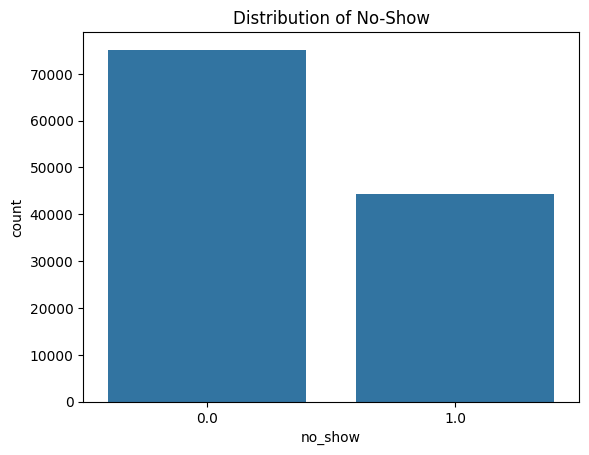

In [34]:
# Distribution of target variable
sns.countplot(data=df, x=target_col)
plt.title('Distribution of No-Show')
plt.show()

In [35]:
# Unique values table
unique_values_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Number of Unique Values": [df[col].nunique() for col in df.columns],
    "Sample Unique Values": [df[col].unique()[:10] for col in df.columns],
    "Number of Missing Values": [df[col].isnull().sum() for col in df.columns],
    "Percentage Missing": [round((df[col].isnull().sum() / len(df)) * 100, 2) for col in df.columns]
})

unique_values_table

,Column,Data Type,Number of Unique Values,Sample Unique Values,Number of Missing Values,Percentage Missing
booking_id,booking_id,int64,119391,"[94113, 86543, 75928, 66947, 106390, 55212, 42322, 23137, 109456, 31117]",0,0.00
no_show,no_show,float64,2,"[0.0, 1.0, nan]",1,0.00
branch,branch,str,2,"[Changi, Orchard, nan]",1,0.00
booking_month,booking_month,str,12,"[November, August, March, September, July, January, October, June, December, April]",1,0.00
arrival_month,arrival_month,str,88,"[June, November, February, October, September, March, May, August, July, January]",1,0.00
arrival_day,arrival_day,float64,31,"[25.0, 28.0, 7.0, 1.0, 20.0, 12.0, 15.0, 18.0, 27.0, 22.0]",1,0.00
checkout_month,checkout_month,str,12,"[June, November, February, October, September, March, May, August, July, January]",1,0.00
checkout_day,checkout_day,float64,62,"[27.0, 29.0, 11.0, 3.0, 24.0, 13.0, 16.0, 19.0, 28.0, 10.0]",1,0.00
country,country,str,7,"[Singapore, Indonesia, India, China, Australia, Japan, Malaysia, nan]",1,0.00
first_time,first_time,str,2,"[Yes, No, nan]",1,0.00


In [36]:
#booking_id: Drop this as it's a unique identifier and won't help in modeling
#There is 1 missing value observed in many of the features. Need to verify if it belongs to the same record and if so, drop the record as well. It is neligible compared to the overall dataset size and won't impact modeling.
# Good to create new columns for duration of stays by taking the difference between arrival and checkout dates. This can be predictor of no-shows.
#check_day: There are negative values observed. Need to verify if this is a data entry error or if it has any significance. 
# room: There are missing room types. Need to verify if this can be referenced from price information. 
#num_adults and num_children are categorized as categorical variables.

In [37]:
# For other columns, we can impute or drop, but let's see which have missing
missing_cols = df.columns[df.isnull().sum() > 0]

# Show the actual rows with missing values
if len(missing_cols) > 0:
    print("\nRows with missing values:")
    for col in missing_cols:
        missing_rows = df[df[col].isnull()]
        print(f"\n{col} - {len(missing_rows)} missing records:")
        print(missing_rows)
else:
    print("\nNo missing values found.")


Rows with missing values:

no_show - 1 missing records:
        booking_id  no_show branch booking_month arrival_month  arrival_day  \
111598      115536      NaN    NaN           NaN           NaN          NaN   

       checkout_month  checkout_day country first_time room price platform  \
111598            NaN           NaN     NaN        NaN  NaN   NaN      NaN   

       num_adults  num_children  
111598        NaN           NaN  

branch - 1 missing records:
        booking_id  no_show branch booking_month arrival_month  arrival_day  \
111598      115536      NaN    NaN           NaN           NaN          NaN   

       checkout_month  checkout_day country first_time room price platform  \
111598            NaN           NaN     NaN        NaN  NaN   NaN      NaN   

       num_adults  num_children  
111598        NaN           NaN  

booking_month - 1 missing records:
        booking_id  no_show branch booking_month arrival_month  arrival_day  \
111598      115536      NaN    

In [38]:
# Drop the row with booking_id 115536
df = df[df['booking_id'] != 115536].reset_index(drop=True)
print(f"Dropped booking_id 115536. New shape: {df.shape}")

Dropped booking_id 115536. New shape: (119390, 15)


In [39]:
# Recheck missing values after dropping booking_id 115536
print("Missing values after dropping booking_id 115536:")
print(df.isnull().sum())

missing_cols_updated = df.columns[df.isnull().sum() > 0]
print("\nColumns with missing values:", missing_cols_updated.tolist())

Missing values after dropping booking_id 115536:
booking_id            0
no_show               0
branch                0
booking_month         0
arrival_month         0
arrival_day           0
checkout_month        0
checkout_day          0
country               0
first_time            0
room              21612
price             24881
platform              0
num_adults            0
num_children          0
dtype: int64

Columns with missing values: ['room', 'price']


In [40]:
df[df['checkout_day'] < 0][[
    'arrival_month',
    'arrival_day',
    'checkout_month',
    'checkout_day',
]]

# it seems to be a data entry error. I will validate if the negative checkout_day appears in the same month as arrival_month.

,arrival_month,arrival_day,checkout_month,checkout_day
43,October,3.0,October,-4.0
69,September,7.0,September,-10.0
99,January,1.0,January,-3.0
117,October,5.0,October,-6.0
160,June,3.0,June,-5.0
...,...,...,...,...
119270,August,2.0,August,-7.0
119345,March,15.0,March,-18.0
119370,May,26.0,May,-27.0
119373,February,15.0,February,-16.0


In [41]:
# Check records where checkout_day is negative
negative_checkout_day_df = df[df['checkout_day'] < 0]
print('Rows where checkout_day < 0:')
print(negative_checkout_day_df)

Rows where checkout_day < 0:
        booking_id  no_show   branch booking_month arrival_month  arrival_day  \
43           76711      1.0  Orchard          July       October          3.0   
69           59927      1.0  Orchard        August     September          7.0   
99           53781      0.0   Changi          July       January          1.0   
117         104943      1.0   Changi     September       October          5.0   
160          11871      1.0   Changi       January          June          3.0   
...            ...      ...      ...           ...           ...          ...   
119270       98681      0.0   Changi      December        August          2.0   
119345      109300      1.0   Changi          July         March         15.0   
119370       96230      0.0   Changi        August           May         26.0   
119373      116904      0.0   Changi       January      February         15.0   
119377       91840      0.0  Orchard     September     September         15.0   

In [42]:
# Validate records where checkout_day is negative
negative_checkout_day_check = df.loc[df['checkout_day'] < 0, [
    'arrival_month', 'arrival_day', 'checkout_month', 'checkout_day'
]].copy()

negative_checkout_day_check['checkout_day_abs'] = negative_checkout_day_check['checkout_day'].abs()
negative_checkout_day_check['same_arrival_checkout_month'] = (
    negative_checkout_day_check['arrival_month'].astype(str).str.strip().str.lower()
    == negative_checkout_day_check['checkout_month'].astype(str).str.strip().str.lower()
)
negative_checkout_day_check['arrival_day_smaller_than_checkout_day_abs'] = (
    negative_checkout_day_check['arrival_day'] < negative_checkout_day_check['checkout_day_abs']
)

print(negative_checkout_day_check)
print('\nSame arrival and checkout month counts:')
print(negative_checkout_day_check['same_arrival_checkout_month'].value_counts(dropna=False))
print('\nArrival day smaller than absolute checkout day counts:')
print(negative_checkout_day_check['arrival_day_smaller_than_checkout_day_abs'].value_counts(dropna=False))

       arrival_month  arrival_day checkout_month  checkout_day  \
43           October          3.0        October          -4.0   
69         September          7.0      September         -10.0   
99           January          1.0        January          -3.0   
117          October          5.0        October          -6.0   
160             June          3.0           June          -5.0   
...              ...          ...            ...           ...   
119270        August          2.0         August          -7.0   
119345         March         15.0          March         -18.0   
119370           May         26.0            May         -27.0   
119373      February         15.0       February         -16.0   
119377     September         15.0      September         -16.0   

        checkout_day_abs  same_arrival_checkout_month  \
43                   4.0                         True   
69                  10.0                         True   
99                   3.0            

In [43]:
# Create a crosstab to validate if the False values in both same_arrival_checkout_month and arrival_day_smaller_than_checkout_day_abs match as expected. 
false_match_crosstab = pd.crosstab(
    negative_checkout_day_check['same_arrival_checkout_month'],
    negative_checkout_day_check['arrival_day_smaller_than_checkout_day_abs'],
    dropna=False
)

same_month_false = ~negative_checkout_day_check['same_arrival_checkout_month']
arrival_day_false = ~negative_checkout_day_check['arrival_day_smaller_than_checkout_day_abs']
false_mismatch = negative_checkout_day_check.loc[same_month_false != arrival_day_false]

print('\nCrosstab between both validation flags:')
print(false_match_crosstab)
print('\nFalse match summary:')
print('same_arrival_checkout_month False:', same_month_false.sum())
print('arrival_day_smaller_than_checkout_day_abs False:', arrival_day_false.sum())
print('matching False rows:', (same_month_false & arrival_day_false).sum())
print('same_arrival_checkout_month False only:', (same_month_false & ~arrival_day_false).sum())
print('arrival_day_smaller_than_checkout_day_abs False only:', (~same_month_false & arrival_day_false).sum())

print('\nRows where the False values do not match:')
display(false_mismatch)


Crosstab between both validation flags:
arrival_day_smaller_than_checkout_day_abs  False  True 
same_arrival_checkout_month                            
False                                        409      1
True                                           0   5286

False match summary:
same_arrival_checkout_month False: 410
arrival_day_smaller_than_checkout_day_abs False: 409
matching False rows: 409
same_arrival_checkout_month False only: 1
arrival_day_smaller_than_checkout_day_abs False only: 0

Rows where the False values do not match:


,arrival_month,arrival_day,checkout_month,checkout_day,checkout_day_abs,same_arrival_checkout_month,arrival_day_smaller_than_checkout_day_abs
67116,January,6.0,February,-10.0,10.0,False,True


In [44]:
#We can safely conclude that the 409 records matches. We can remove these records as they are small in number.
#for the remaining 5286 records, the checkout_day is likely a data entry error and we can resolve this by taking the absolute value.

negative_checkout_mask = df['checkout_day'] < 0
checkout_day_abs = df['checkout_day'].abs()

same_arrival_checkout_month = (
    df['arrival_month'].astype(str).str.strip().str.lower()
    == df['checkout_month'].astype(str).str.strip().str.lower()
)
arrival_day_smaller_than_checkout_day_abs = df['arrival_day'] < checkout_day_abs

drop_invalid_checkout_mask = (
    negative_checkout_mask
    & ~same_arrival_checkout_month
    & ~arrival_day_smaller_than_checkout_day_abs
)

print('Rows before dropping invalid checkout records:', df.shape[0])
print('Invalid checkout records to drop:', drop_invalid_checkout_mask.sum())

df = df.loc[~drop_invalid_checkout_mask].copy()

# Convert checkout_day to absolute value after removing the invalid negative records.
df['checkout_day'] = df['checkout_day'].abs()

month_to_num = {
    'january': 1,
    'february': 2,
    'march': 3,
    'april': 4,
    'may': 5,
    'june': 6,
    'july': 7,
    'august': 8,
    'september': 9,
    'october': 10,
    'november': 11,
    'december': 12,
}

arrival_month_num = df['arrival_month'].astype(str).str.strip().str.lower().map(month_to_num)
checkout_month_num = df['checkout_month'].astype(str).str.strip().str.lower().map(month_to_num)
arrival_day_num = pd.to_numeric(df['arrival_day'], errors='coerce').astype('Int64')
checkout_day_num = pd.to_numeric(df['checkout_day'], errors='coerce').astype('Int64')

arrival_date = pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns]')
checkout_date = pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns]')

valid_arrival_date = arrival_month_num.notna() & arrival_day_num.notna()
valid_checkout_date = checkout_month_num.notna() & checkout_day_num.notna()

arrival_date.loc[valid_arrival_date] = pd.to_datetime(
    pd.DataFrame({
        'year': 2024,
        'month': arrival_month_num.loc[valid_arrival_date].astype(int),
        'day': arrival_day_num.loc[valid_arrival_date].astype(int)
    }),
    errors='coerce'
)
checkout_date.loc[valid_checkout_date] = pd.to_datetime(
    pd.DataFrame({
        'year': 2024,
        'month': checkout_month_num.loc[valid_checkout_date].astype(int),
        'day': checkout_day_num.loc[valid_checkout_date].astype(int)
    }),
    errors='coerce'
)

# Treat checkout dates earlier than arrival dates as crossing into the next year.
checkout_date = checkout_date.mask(checkout_date < arrival_date, checkout_date + pd.DateOffset(years=1))

df['days_difference'] = (checkout_date - arrival_date).dt.days

print('Rows after dropping invalid checkout records:', df.shape[0])
print('Remaining negative checkout_day values:', (df['checkout_day'] < 0).sum())
print('Missing days_difference values:', df['days_difference'].isna().sum())

display(df[['arrival_month', 'arrival_day', 'checkout_month', 'checkout_day', 'days_difference']].head())


Rows before dropping invalid checkout records: 119390
Invalid checkout records to drop: 409
Rows after dropping invalid checkout records: 118981
Remaining negative checkout_day values: 0
Missing days_difference values: 0


,arrival_month,arrival_day,checkout_month,checkout_day,days_difference
0,June,25.0,June,27.0,2
1,November,28.0,November,29.0,1
2,February,7.0,February,11.0,4
3,October,1.0,October,3.0,2
4,June,20.0,June,24.0,4


In [45]:
# Standardize price into SGD using a fixed USD to SGD exchange rate.
USD_TO_SGD_RATE = 1.35

price_text = df['price'].astype('string').str.strip()

price_currency = price_text.str.extract(r'([A-Za-z]{3})', expand=False).str.lower()
price_amount = pd.to_numeric(
    price_text.str.extract(r'(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

df['currency'] = price_currency
df['price'] = price_amount
is_usd = df['currency'].eq('usd').to_numpy(dtype=bool, na_value=False)
is_sgd = df['currency'].eq('sgd').to_numpy(dtype=bool, na_value=False)

df['price_sgd'] = np.select(
    [is_usd, is_sgd],
    [df['price'] * USD_TO_SGD_RATE, df['price']],
    default=np.nan
)
df['price_sgd'] = pd.Series(df['price_sgd'], index=df.index).round(2)

# Standardize num_adults values such as 'one'/'two' into numeric values.
num_adults_mapping = {
    'one': 1,
    'two': 2,
}

num_adults_clean = df['num_adults'].astype('string').str.strip().str.lower().replace(num_adults_mapping)
df['num_adults'] = pd.to_numeric(num_adults_clean, errors='coerce').astype('Int64')

print('Fixed USD to SGD exchange rate:', USD_TO_SGD_RATE)
print('\nCurrency counts:')
print(df['currency'].value_counts(dropna=False))
print('\nnum_adults counts after standardization:')
print(df['num_adults'].value_counts(dropna=False).sort_index())

display(df[['price', 'currency', 'price_sgd', 'num_adults']].head(10))


Fixed USD to SGD exchange rate: 1.35

Currency counts:
currency
sgd     47126
usd     47063
<NA>    24792
Name: count, dtype: Int64

num_adults counts after standardization:
num_adults
1    68818
2    50163
Name: count, dtype: Int64


,price,currency,price_sgd,num_adults
0,492.98,sgd,492.98,1
1,1351.22,sgd,1351.22,2
2,<NA>,<NA>,NaN,1
3,666.04,sgd,666.04,1
4,665.37,usd,898.25,1
5,1499.61,sgd,1499.61,2
6,1375.44,sgd,1375.44,1
7,<NA>,<NA>,NaN,2
8,658.75,usd,889.31,2
9,962.75,usd,1299.71,1


In [46]:
def unique_value_display(col):
    if col == 'days_difference':
        return sorted(df[col].dropna().unique())
    return df[col].unique()[:28]

unique_values_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Number of Unique Values": [df[col].nunique() for col in df.columns],
    "Sample Unique Values": [unique_value_display(col) for col in df.columns],
    "Number of Missing Values": [df[col].isnull().sum() for col in df.columns],
    "Percentage Missing": [round((df[col].isnull().sum() / len(df)) * 100, 2) for col in df.columns]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_seq_items', None)

display(unique_values_table)

print('Full unique values for days_difference:')
print(sorted(df['days_difference'].dropna().unique()))

,Column,Data Type,Number of Unique Values,Sample Unique Values,Number of Missing Values,Percentage Missing
booking_id,booking_id,int64,118981,"[94113, 86543, 75928, 66947, 106390, 55212, 42322, 23137, 109456, 31117, 65862, 108345, 81453, 88243, 115125, 99392, 28623, 85014, 28009, 3158, 96790, 24770, 71495, 93517, 60146, 17827, 114619, 30985]",0,0.00
no_show,no_show,float64,2,"[0.0, 1.0]",0,0.00
branch,branch,str,2,"[Changi, Orchard]",0,0.00
booking_month,booking_month,str,12,"[November, August, March, September, July, January, October, June, December, April, May, February]",0,0.00
arrival_month,arrival_month,str,88,"[June, November, February, October, September, March, May, August, July, January, April, December, ApRiL, OcTobeR, JuNe, JulY, ApriL, OctOber, DecembEr, SeptEmber, JanUary, JUne, FeBruary, JanuarY, DEcember, SePtember, DecembeR, MaY]",0,0.00
arrival_day,arrival_day,float64,31,"[25.0, 28.0, 7.0, 1.0, 20.0, 12.0, 15.0, 18.0, 27.0, 22.0, 9.0, 11.0, 10.0, 13.0, 30.0, 21.0, 5.0, 6.0, 2.0, 31.0, 19.0, 4.0, 3.0, 23.0, 17.0, 8.0, 26.0, 14.0]",0,0.00
checkout_month,checkout_month,str,12,"[June, November, February, October, September, March, May, August, July, January, April, December]",0,0.00
checkout_day,checkout_day,float64,31,"[27.0, 29.0, 11.0, 3.0, 24.0, 13.0, 16.0, 19.0, 28.0, 10.0, 12.0, 15.0, 23.0, 31.0, 25.0, 17.0, 8.0, 2.0, 9.0, 7.0, 1.0, 20.0, 14.0, 4.0, 6.0, 21.0, 5.0, 18.0]",0,0.00
country,country,str,7,"[Singapore, Indonesia, India, China, Australia, Japan, Malaysia]",0,0.00
first_time,first_time,str,2,"[Yes, No]",0,0.00


Full unique values for days_difference:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(21), np.int64(22), np.int64(23), np.int64(28), np.int64(29), np.int64(30), np.int64(35), np.int64(40), np.int64(42), np.int64(43), np.int64(44), np.int64(46), np.int64(49), np.int64(54), np.int64(57), np.int64(62), np.int64(64)]


In [47]:
# Data cleaning
# Convert Price to SGD using a fixed exchange rate and create a new column price_sgd.
USD_TO_SGD_RATE = 1.35

if 'price_sgd' not in df.columns:
    price_text = df['price'].astype('string').str.strip()
    df['currency'] = price_text.str.extract(r'([A-Za-z]{3})', expand=False).str.lower()
    df['price'] = pd.to_numeric(
        price_text.str.extract(r'(\d+(?:\.\d+)?)', expand=False),
        errors='coerce'
    )
    is_usd = df['currency'].eq('usd').to_numpy(dtype=bool, na_value=False)
    is_sgd = df['currency'].eq('sgd').to_numpy(dtype=bool, na_value=False)

    df['price_sgd'] = np.select(
        [is_usd, is_sgd],
        [df['price'] * USD_TO_SGD_RATE, df['price']],
        default=np.nan
    )
    df['price_sgd'] = pd.Series(df['price_sgd'], index=df.index).round(2)


#Standardize num_adults values such as 'one'/'two' into numeric values.
word_to_num = {'one': 1, 'two': 2}
num_adults_clean = df['num_adults'].astype('string').str.strip().str.lower().replace(word_to_num)
df['num_adults'] = pd.to_numeric(num_adults_clean, errors='coerce').astype('Int64')
df['num_children'] = pd.to_numeric(df['num_children'], errors='coerce').astype('Int64')

#Drop Price and currency columns as we have standardized price_sgd column. 
df = df.drop(columns=['price', 'currency'])
#Drop arrival_day and checkout_day as we have created days_difference column which is more useful for modeling.
df = df.drop(columns=['arrival_day', 'checkout_day'])


# Ensure categorical columns are strings
categorical_cols = ['branch', 'booking_month', 'arrival_month', 'checkout_month', 'country', 'first_time', 'room', 'platform', 'num_children', 'num_adults']
for col in categorical_cols:
    if col not in ['num_children', 'num_adults']:
        df[col] = df[col].astype('string').str.strip().str.lower()


print("Data types after cleaning:")
print(df.dtypes)
display(df.head())

Data types after cleaning:
booking_id           int64
no_show            float64
branch              string
booking_month       string
arrival_month       string
checkout_month      string
country             string
first_time          string
room                string
platform            string
num_adults           Int64
num_children         Int64
days_difference      int64
price_sgd          float64
dtype: object


,booking_id,no_show,branch,booking_month,arrival_month,checkout_month,country,first_time,room,platform,num_adults,num_children,days_difference,price_sgd
0,94113,0.0,changi,november,june,june,singapore,yes,single,website,1,0,2,492.98
1,86543,0.0,orchard,august,november,november,indonesia,yes,king,website,2,0,1,1351.22
2,75928,0.0,changi,march,february,february,india,yes,single,agent,1,0,4,NaN
3,66947,1.0,orchard,september,october,october,china,yes,single,website,1,0,2,666.04
4,106390,0.0,orchard,march,june,june,australia,yes,queen,website,1,0,4,898.25


In [48]:
#treat missing as its own category for Rooms
df['room'] = df['room'].astype('string').str.strip().str.lower()
df['room'] = df['room'].fillna('missing')

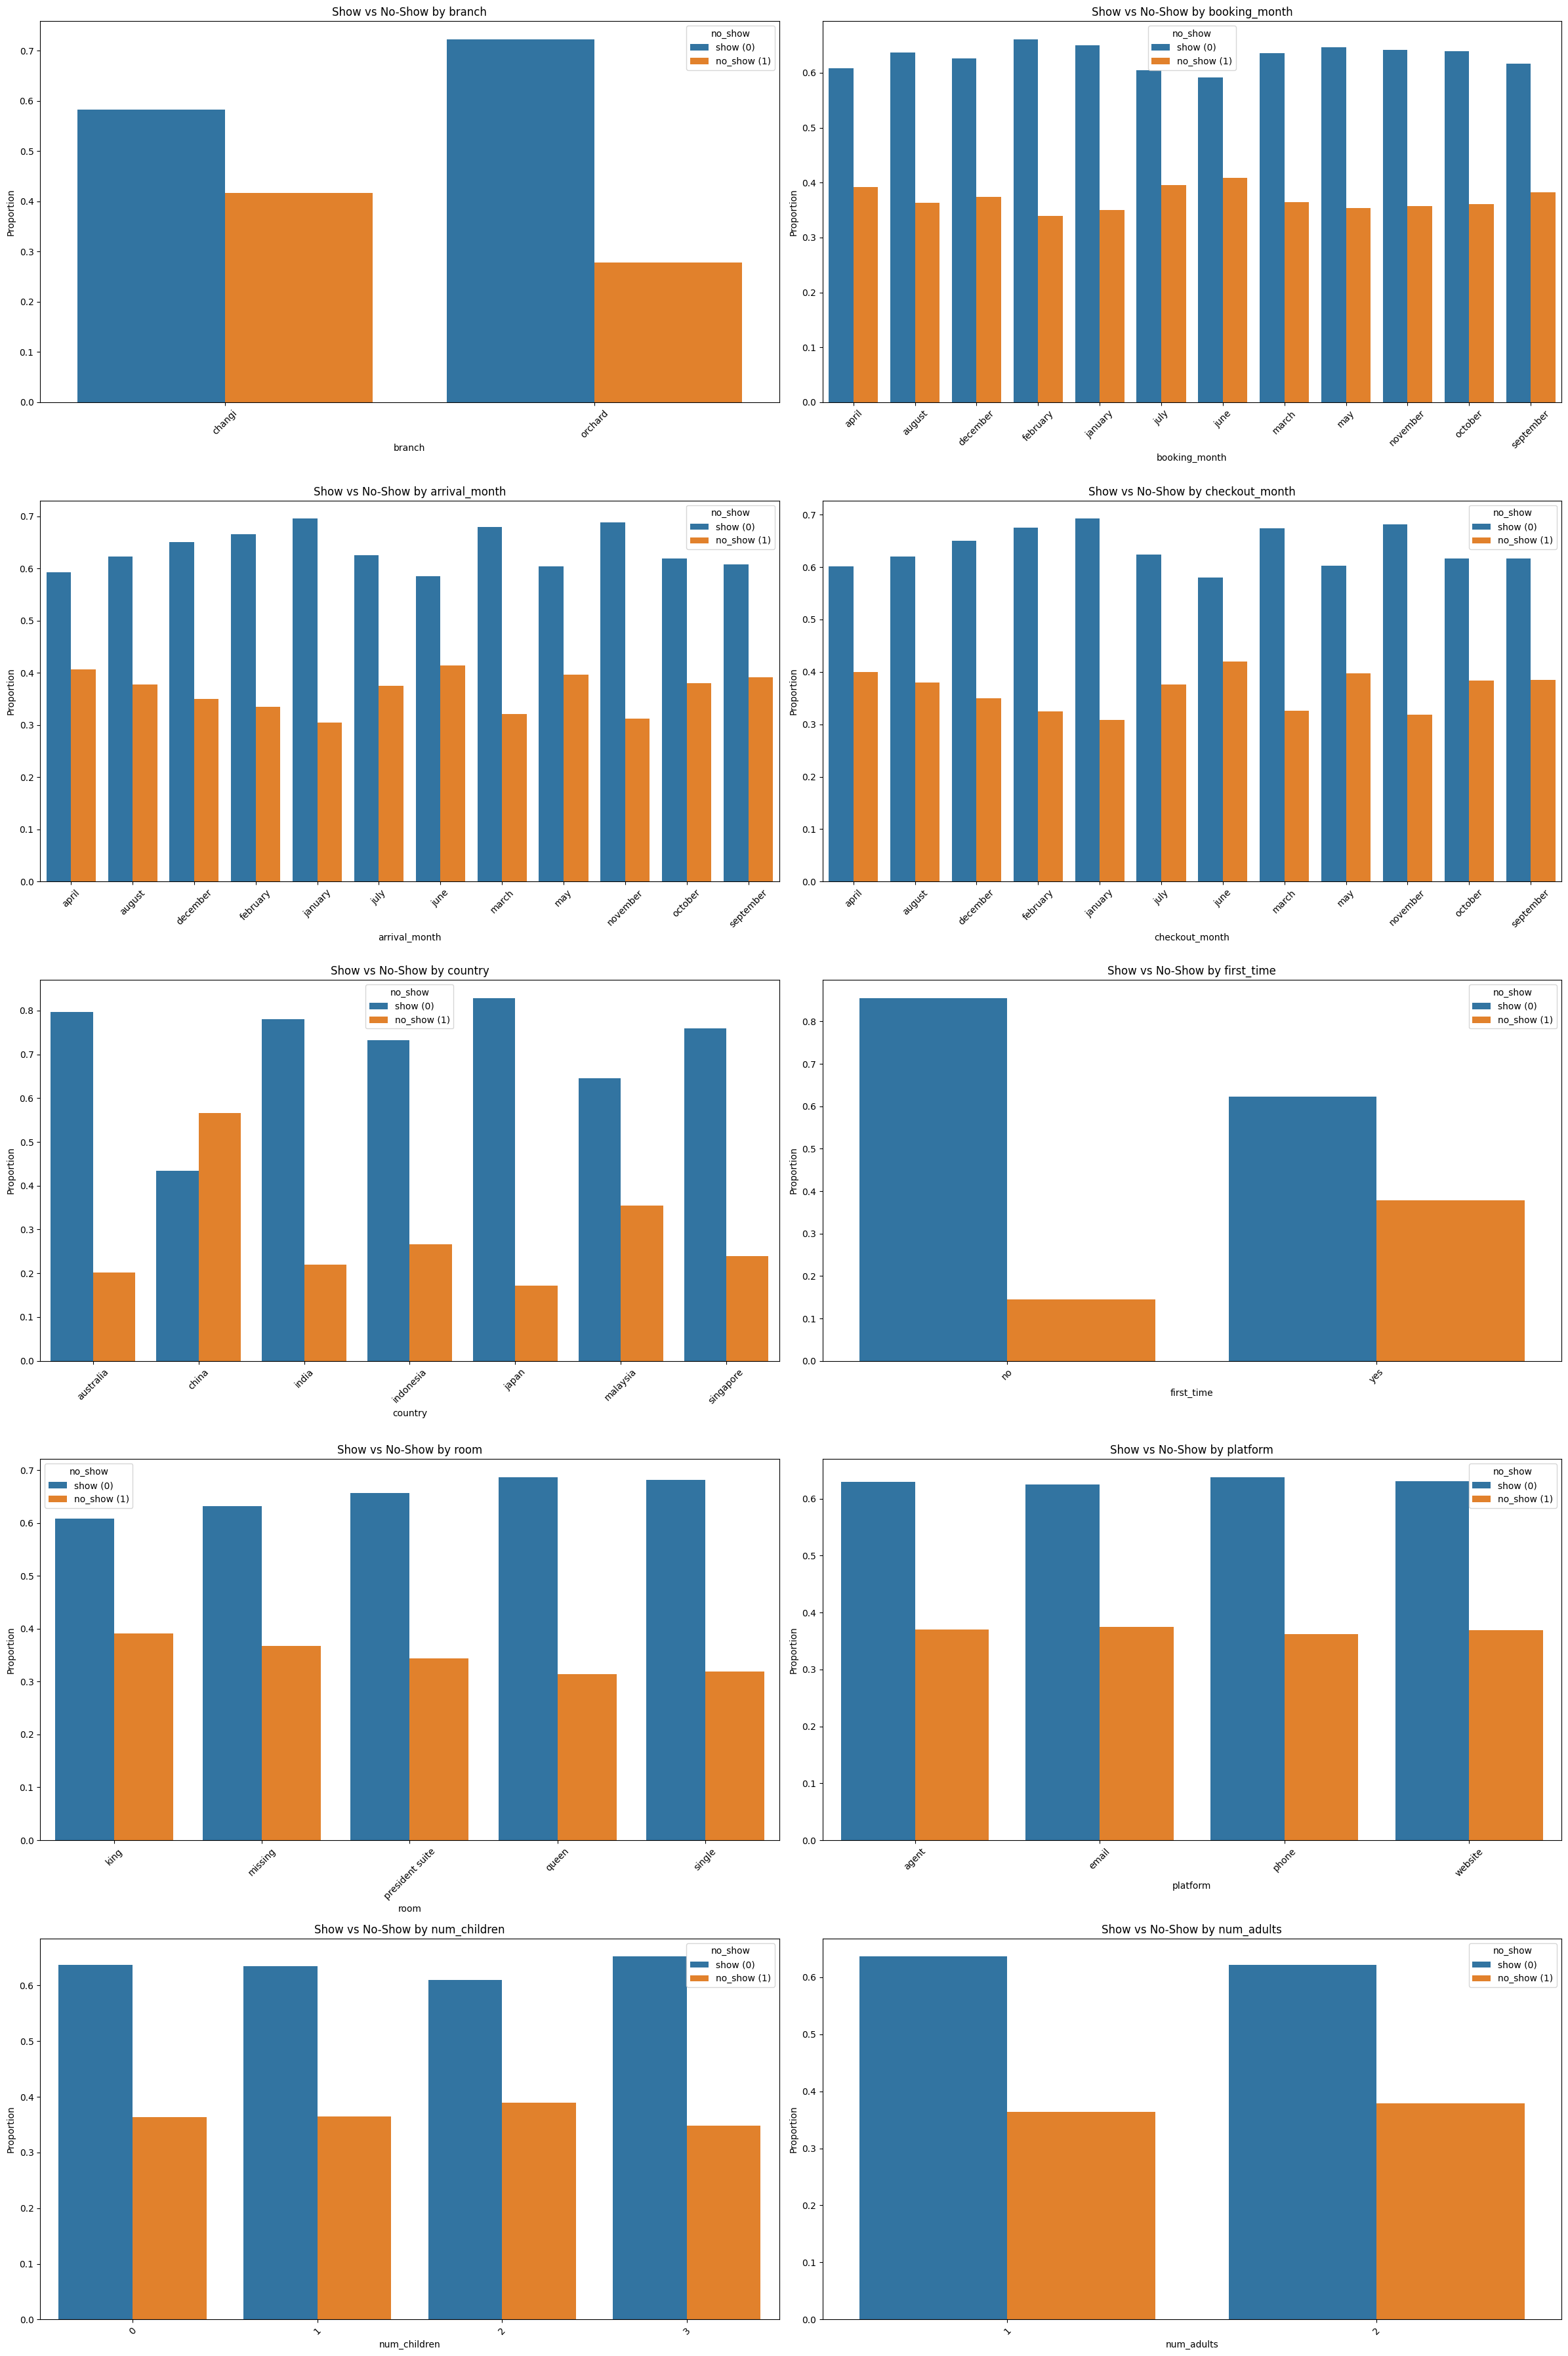

In [49]:
# Analyze categorical variables vs target
fig, axes = plt.subplots(5, 2, figsize=(24, 36))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = df.groupby([col, target_col]).size().rename('count').reset_index()
    counts['proportion'] = counts['count'] / counts.groupby(col)['count'].transform('sum')
    counts[target_col] = counts[target_col].map({0: 'show (0)', 1: 'no_show (1)', '0': 'show (0)', '1': 'no_show (1)'})

    sns.barplot(data=counts, x=col, y='proportion', hue=target_col, ax=ax)
    ax.set_title(f'Show vs No-Show by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
    # counts['proportion'] = counts['count'] / counts.groupby(col)['count'].transform('sum')
    # counts[target_col] = counts[target_col].map({0: 'show (0)', 1: 'no_show (1)', '0': 'show (0)', '1': 'no_show (1)'})

    # sns.barplot(data=counts, x=col, y='proportion', hue=target_col, ax=ax)
    # ax.set_title(f'Show vs No-Show by {col}')
    # ax.set_xlabel(col)
    # ax.set_ylabel('Proportion')
    # ax.tick_params(axis='x', rotation=45)


In [50]:
#Drop checkout_month as the behaviour of no-shows is similar to arrival_month. This will also help reduce dimensionality and avoid multicollinearity in modeling.
df = df.drop(columns=['checkout_month'])

#no difference in the distibution of no-shows for platform and num_adults. Dropping these columns to further reduce dimensionality and avoid multicollinearity in modeling.
df=df.drop(columns=['platform', 'num_adults'])


In [51]:
# Side-by-side profile: missing price_sgd vs present price_sgd
df['price_sgd_missing'] = df['price_sgd'].isna()

profile_cols = [
    'no_show',
    'branch',
    'country',
    'room',
    'num_children',
    'first_time'
]

for col in profile_cols:
    comparison = (
        pd.crosstab(
            df[col],
            df['price_sgd_missing'],
            normalize='columns',
            dropna=False
        )
        .mul(100)
        .round(2)
        .rename(columns={
            False: 'price_sgd present (%)',
            True: 'price_sgd missing (%)'
        })
    )

    comparison['difference_missing_minus_present'] = (
        comparison['price_sgd missing (%)']
        - comparison['price_sgd present (%)']
    ).round(2)

    comparison = comparison.sort_values(
        'difference_missing_minus_present',
        key=lambda s: s.abs(),
        ascending=False
    )

    print(f"\nSide-by-side comparison for {col}:")
    display(comparison)


Side-by-side comparison for no_show:


price_sgd_missing,price_sgd present (%),price_sgd missing (%),difference_missing_minus_present
no_show,,,
0.0,63.01,62.84,-0.17
1.0,36.99,37.16,0.17



Side-by-side comparison for branch:


price_sgd_missing,price_sgd present (%),price_sgd missing (%),difference_missing_minus_present
branch,,,
changi,66.64,65.83,-0.81
orchard,33.36,34.17,0.81



Side-by-side comparison for country:


...

price_sgd_missing,price_sgd present (%),price_sgd missing (%),difference_missing_minus_present
room,,,
missing,22.85,0.00,-22.85
king,55.66,72.04,16.38
single,12.40,15.96,3.56
queen,8.50,11.16,2.66
president suite,0.58,0.84,0.26



Side-by-side comparison for num_children:


price_sgd_missing,price_sgd present (%),price_sgd missing (%),difference_missing_minus_present
num_children,,,
0,37.51,37.28,-0.23
1,38.13,38.28,0.15
2,24.15,24.21,0.06
3,0.20,0.22,0.02



Side-by-side comparison for first_time:


price_sgd_missing,price_sgd present (%),price_sgd missing (%),difference_missing_minus_present
first_time,,,
no,3.18,3.24,0.06
yes,96.82,96.76,-0.06


In [52]:
#Looking at the above dataset, the price_sgd is likely related to the room type. We cannot drop the missing records as they are significant at 20%. 
#we can group them via room type and use a median price imputation strategy to fill in the missing price_sgd values. This will help us retain the records while also providing a reasonable estimate for the missing prices based on room type.

# Create missingness indicator
df['price_sgd_missing'] = df['price_sgd'].isna().astype(int)

# Impute price_sgd using median by room + branch
group_median_price = df.groupby(['room'])['price_sgd'].transform('median')

df['price_sgd_imputed'] = df['price_sgd'].fillna(group_median_price)

# Fallback to room-level median
room_median_price = df.groupby('room')['price_sgd'].transform('median')
df['price_sgd_imputed'] = df['price_sgd_imputed'].fillna(room_median_price)

# Final fallback to overall median
df['price_sgd_imputed'] = df['price_sgd_imputed'].fillna(df['price_sgd'].median())

# Check
print("Missing price_sgd before:", df['price_sgd'].isna().sum())
print("Missing price_sgd_imputed after:", df['price_sgd_imputed'].isna().sum())

display(
    df[['price_sgd', 'price_sgd_imputed', 'price_sgd_missing', 'room']]
    .head(10)
)

Missing price_sgd before: 24792
Missing price_sgd_imputed after: 0


,price_sgd,price_sgd_imputed,price_sgd_missing,room
0,492.98,492.98,0,single
1,1351.22,1351.22,0,king
2,NaN,558.63,1,single
3,666.04,666.04,0,single
4,898.25,898.25,0,queen
5,1499.61,1499.61,0,missing
6,1375.44,1375.44,0,king
7,NaN,930.33,1,king
8,889.31,889.31,0,missing
9,1299.71,1299.71,0,missing


In [53]:
#drop original price_sgd and price_sgd_missing columns as we have the imputed version now.
df = df.drop(columns=['price_sgd', 'price_sgd_missing'])

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


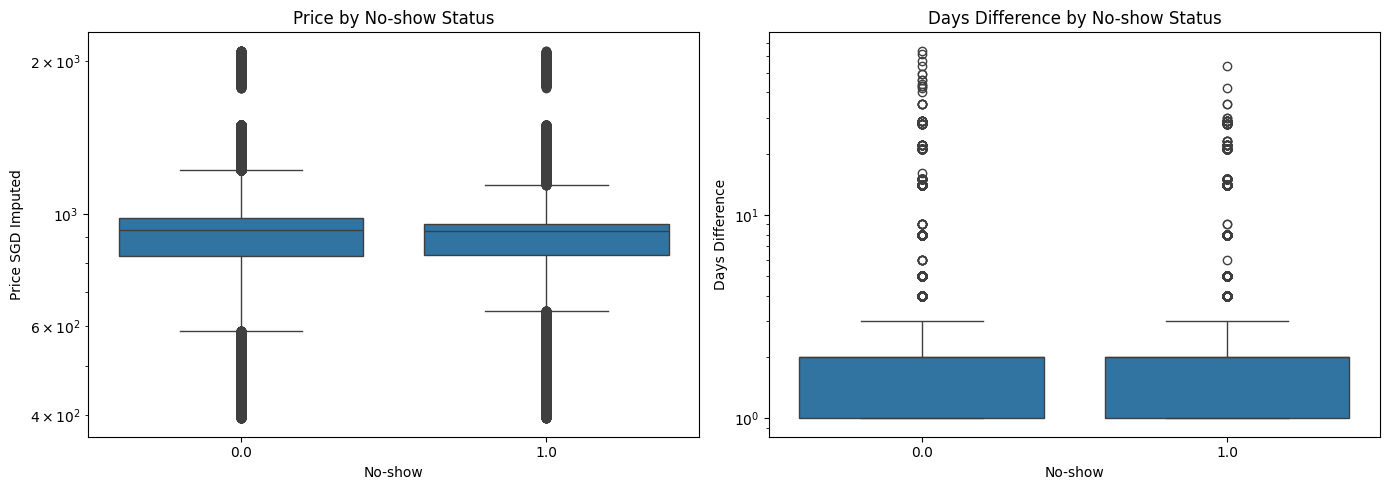

In [61]:
# Analyze numerical variables by no-show status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='no_show', y='price_sgd_imputed', ax=axes[0])
axes[0].set_title('Price by No-show Status')
axes[0].set_xlabel('No-show')
axes[0].set_ylabel('Price SGD Imputed')
axes[0].set_yscale('log')

sns.boxplot(data=df, x='no_show', y='days_difference', ax=axes[1])
axes[1].set_title('Days Difference by No-show Status')
axes[1].set_xlabel('No-show')
axes[1].set_ylabel('Days Difference')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
#price_sgd_imputed: there is visible difference in the distribution of price_sgd_imputed by no-show status. We can further validate this by looking at the summary statistics by no-show status.
summary_stats = df.groupby('no_show')['price_sgd_imputed'].describe()
print("Summary statistics of price_sgd_imputed by no-show status:")
print(summary_stats)

Summary statistics of price_sgd_imputed by no-show status:
           count        mean         std     min     25%     50%     75%  \
no_show                                                                    
0.0      74923.0  938.587266  260.261733  394.40  823.79  930.33  982.31   
1.0      44058.0  914.615706  225.834944  394.21  830.14  926.63  954.63   

             max  
no_show           
0.0      2099.96  
1.0      2098.37  

 Summary statistics of days_difference by no-show status:
           count      mean       std  min  25%  50%  75%   max
no_show                                                       
0.0      74923.0  2.073329  2.157963  1.0  1.0  2.0  2.0  64.0
1.0      44058.0  2.161197  2.163805  1.0  1.0  2.0  2.0  54.0


In [ ]:
# Days_difference: no visible difference in the distribution of days_difference by no-show status. We can further validate this by looking at the summary statistics by no-show status.
summary_stats_days = df.groupby('no_show')['days_difference'].describe()
print("\n Summary statistics of days_difference by no-show status:")
print(summary_stats_days)

#Suggest to drop the days_difference column as it does not show significant difference by no-show status and to reduce dimensionality for modeling. 
df = df.drop(columns=['days_difference'])

In [70]:
# Final unique values table
max_unique_values = 12

def unique_value_display_final(col, max_values=max_unique_values):
    return df[col].dropna().unique()[:max_values]

unique_values_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Number of Unique Values": [df[col].nunique() for col in df.columns],
    "Sample Unique Values": [unique_value_display_final(col) for col in df.columns],
    "Number of Missing Values": [df[col].isnull().sum() for col in df.columns],
    "Percentage Missing": [round((df[col].isnull().sum() / len(df)) * 100, 2) for col in df.columns]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_seq_items', None)

display(unique_values_table)

,Column,Data Type,Number of Unique Values,Sample Unique Values,Number of Missing Values,Percentage Missing
booking_id,booking_id,int64,118981,"[94113, 86543, 75928, 66947, 106390, 55212, 42322, 23137, 109456, 31117, 65862, 108345]",0,0.0
no_show,no_show,float64,2,"[0.0, 1.0]",0,0.0
branch,branch,string,2,"[changi, orchard]",0,0.0
booking_month,booking_month,string,12,"[november, august, march, september, july, january, october, june, december, april, may, february]",0,0.0
arrival_month,arrival_month,string,12,"[june, november, february, october, september, march, may, august, july, january, april, december]",0,0.0
country,country,string,7,"[singapore, indonesia, india, china, australia, japan, malaysia]",0,0.0
first_time,first_time,string,2,"[yes, no]",0,0.0
room,room,string,5,"[single, king, queen, missing, president suite]",0,0.0
num_children,num_children,Int64,4,"[0, 2, 1, 3]",0,0.0
price_sgd_imputed,price_sgd_imputed,float64,49724,"[492.98, 1351.22, 558.63, 666.04, 898.25, 1499.61, 1375.44, 930.33, 889.31, 1299.71, 1478.01, 867.99]",0,0.0


In [71]:
print("Final shape:", df.shape)

Final shape: (118981, 10)


In [58]:
# Next steps:
# 1. Determine models: Logistic Regression, Random Forest, XGBoost. Why? These models are suitable for binary classification, can handle non-linear relationships, and feature interactions. Random Forest and XGBoost are ensemble methods that can capture complex patterns and are robust to overfitting.
# 2. Ensure OneHotEncoding is applied to categorical features. StandardScaler is not needed as tree-based models are not affected by feature scales.
# 3. Consider feature engineering: e.g., total guests = num_adults + num_children, or price categories.
# 4. Handle class imbalance if needed (SMOTE or class weights).
# 5. Evaluate with AUC-ROC, precision, recall, etc.

In [59]:
# Check unique values for price
print("price_sgd_imputed unique sample:", df['price_sgd_imputed'].unique()[:10])

price_sgd_imputed unique sample: [ 492.98 1351.22  558.63  666.04  898.25 1499.61 1375.44  930.33  889.31
 1299.71]


In [60]:
print('Columns:', df.columns.tolist())

Columns: ['booking_id', 'no_show', 'branch', 'booking_month', 'arrival_month', 'country', 'first_time', 'room', 'num_children', 'days_difference', 'price_sgd_imputed']
